# Scenario discovery: PRIM and CART on the refined desired region

Same workflow as [handson_scenariodiscovery.ipynb](handson_scenariodiscovery.ipynb) (CART first for an
easy-to-read tree, then PRIM for a tuned box), applied to our own dataset and our own outcome:

**`desired_success`** = reaches net-zero CO2 by 2070 **and** has below-median cumulative CCS reliance
(built in [01_build_dataset.ipynb](01_build_dataset.ipynb)). Unlike the handson notebook we don't need
a binarization step - the outcome is already binary by construction, and the threshold choices behind
it (NZ year, CCS median split) were already made deliberately in the build step.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ema_workbench.analysis import cart, prim

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

/Users/a.salgas/summer_robust_decision_making/.venv/lib/python3.11/site-packages/ema_workbench/em_framework/__init__.py:101: UserWarning: ipyparallel not installed - IpyparalleEvaluator not available
  warnings.warn("ipyparallel not installed - IpyparalleEvaluator not available")


In [2]:
data = pd.read_csv("data_for_scenariodiscovery_full.csv")
print(data.shape)
data[["Model", "Scenario", "success_nz2070", "low_ccs_reliance", "desired_success"]].head()

(1599, 339)


,Model,Scenario,success_nz2070,low_ccs_reliance,desired_success
0,AIM/CGE 2.0,SSP1-19,True,True,True
1,AIM/CGE 2.0,SSP1-26,False,True,False
2,AIM/CGE 2.0,SSP1-34,False,True,False
3,AIM/CGE 2.0,SSP1-45,False,True,False
4,AIM/CGE 2.0,SSP1-Baseline,False,False,False


## 1. Choose outcome and explanatory factors

Outcome: `desired_success`.

Factors are pathway-descriptor snapshots, deliberately **excluding** anything used to construct the
outcome itself (to avoid circularity - same caveat as the README's "excluding 2070 CO2" robustness
check):

- excluded `Emissions|CO2` at/after 2050 and the meta `Year of Net Zero` field - these are how
  `success_nz2070` is defined.
- excluded `Carbon Capture|Geological Storage` (level and ramp-pace) and the meta `Cumulative CCS`
  field - these are how `low_ccs_reliance` is defined.
- excluded `Carbon Removal|Land Use` - not circular, but 36% missing; dropping it keeps 1165/1599
  scenarios instead of 788 (see below), a better trade for PRIM/CART sample size.

What's left: early CO2 trajectory (2030, still a legitimate leading indicator, not part of the
outcome definition), the 2050 energy-supply mix, GDP/population context, and - new - the **ramp-up
pace** of renewables and electrification (`late_growth_share`: fraction of 2020-2060 growth that
happens in 2040-2060 rather than 2020-2040), to test whether *how* a technology is built out matters
beyond just its 2050 level.

In [ ]:
OUTCOME = "desired_success"

FACTORS = [
    "Emissions|CO2|2030",
    "Primary Energy|Fossil|2030",
    "Primary Energy|Fossil|2050",
    "Primary Energy|Non-Biomass Renewables|2030",
    "Primary Energy|Non-Biomass Renewables|2050",
    "Primary Energy|Biomass|2050",
    "Primary Energy|Nuclear|2050",
    "Final Energy|2050",
    "Final Energy|Electricity|2050",
    "GDP per capita|PPP|2050",
    "Population|2050",
    # "Primary Energy|Non-Biomass Renewables|late_growth_share",  # ramp-up pace, 2040-60 share of 2020-60 growth
    # "Final Energy|Electricity|late_growth_share",
]

sub = data[FACTORS + [OUTCOME]].dropna()
x = sub[FACTORS]
y = sub[OUTCOME].values

print(f"{len(sub)}/{len(data)} scenarios with complete data on all {len(FACTORS)} factors")
print(f"{y.sum()} cases of interest (desired_success), baseline density = {y.mean():.1%}")

1147/1599 scenarios with complete data on all 13 factors
273 cases of interest (desired_success), baseline density = 23.8%


## 2. CART: an easy-to-read decision tree

Per the methodology reference, CART is mainly for **communication** - a full partition of the space
with a leaf-by-leaf readout, even though PRIM (next section) is the main scenario-discovery tool.

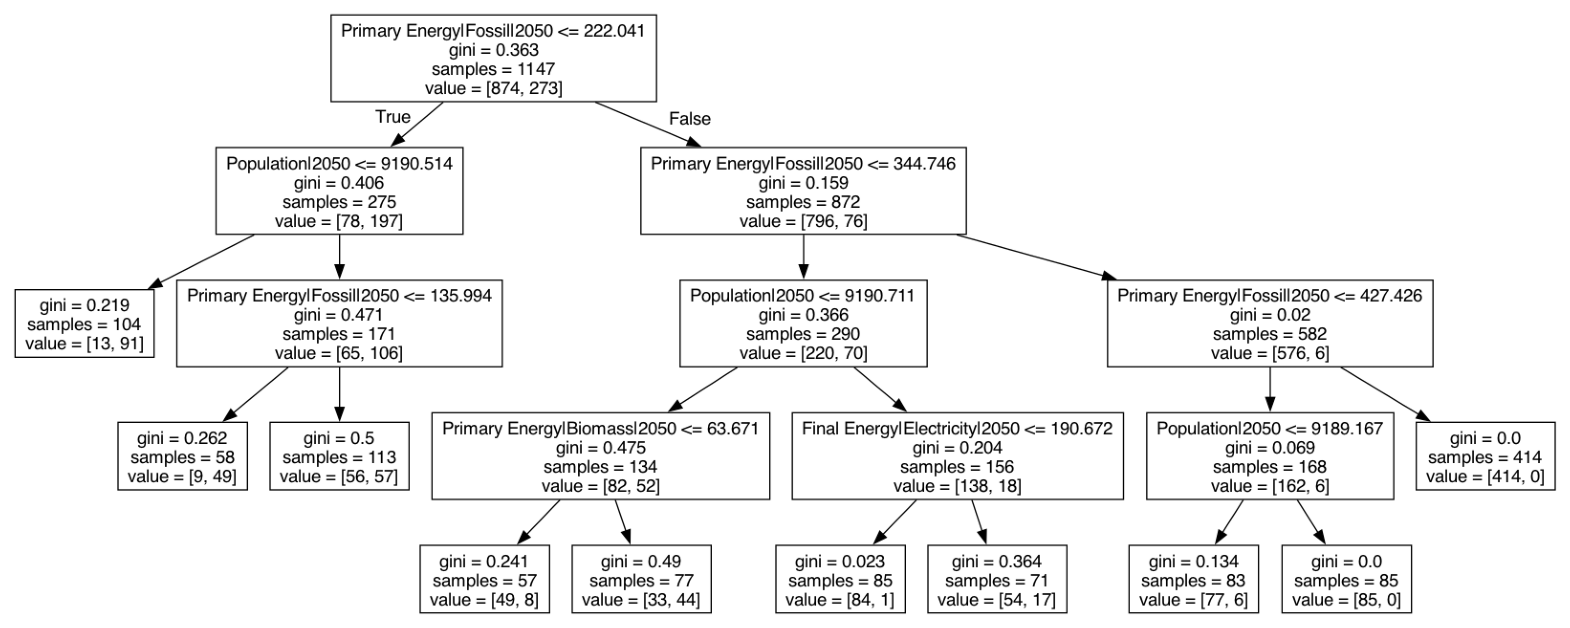

In [4]:
cart_alg = cart.CART(x, y)
cart_alg.build_tree()

fig = cart_alg.show_tree()
fig.set_size_inches((20, 13))
fig.savefig("cart_tree_desired_success.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Feature importances from the underlying sklearn tree - which splits did CART actually use
importances = pd.Series(
    cart_alg.clf.feature_importances_, index=FACTORS
).sort_values(ascending=False)
importances[importances > 0]

Primary Energy|Fossil|2050       0.845302
Population|2050                  0.084686
Primary Energy|Biomass|2050      0.052662
Final Energy|Electricity|2050    0.017350
dtype: float64

## 2b. CART with the full pathway-variable set

The curated `FACTORS` list above is a deliberate, hand-picked subset. Here we instead throw in
**every** non-circular pathway variable we've built, at every commonly-reported year (2020-2050
every 5 years, then 2060/70/80/90/100), plus all the ramp-pace features - and let CART pick whatever
splits reduce impurity most, regardless of which year or variable that turns out to be.

Still excluded for circularity: `Carbon Capture|Geological Storage` (any year, defines
`low_ccs_reliance`), the meta `Cumulative CCS`/`Year of Net Zero` fields, and `Emissions|CO2` at/after
2050 (too close to the net-zero-year definition). Sparse off-cycle years (2055/65/75/85/95) and
`Carbon Removal|Land Use` are dropped purely because of how much sample size they cost via `dropna`,
not for circularity.

In [6]:
YEARS = [2020, 2025, 2030, 2035, 2040, 2045, 2050, 2060, 2070, 2080, 2090, 2100]
BASE_VARS = [
    "Final Energy", "Final Energy|Electricity", "Primary Energy", "Primary Energy|Biomass",
    "Primary Energy|Fossil", "Primary Energy|Non-Biomass Renewables", "Primary Energy|Nuclear",
    "GDP|PPP", "Population", "GDP per capita|PPP",
]

ALL_FACTORS = [f"{v}|{y}" for v in BASE_VARS for y in YEARS]
ALL_FACTORS += [f"Emissions|CO2|{y}" for y in YEARS if y <= 2045]
ALL_FACTORS += [
    c for c in data.columns
    if ("late_growth_share" in c or "growth_2020_2040" in c or "growth_2040_2060" in c)
    and "Carbon Capture" not in c
]

sub_all = data[ALL_FACTORS + [OUTCOME]].dropna()
x_all = sub_all[ALL_FACTORS]
y_all = sub_all[OUTCOME].values

print(f"{len(ALL_FACTORS)} candidate factors")
print(f"{len(sub_all)}/{len(data)} scenarios with complete data")
print(f"{y_all.sum()} cases of interest, baseline density = {y_all.mean():.1%}")

135 candidate factors
1052/1599 scenarios with complete data
247 cases of interest, baseline density = 23.5%


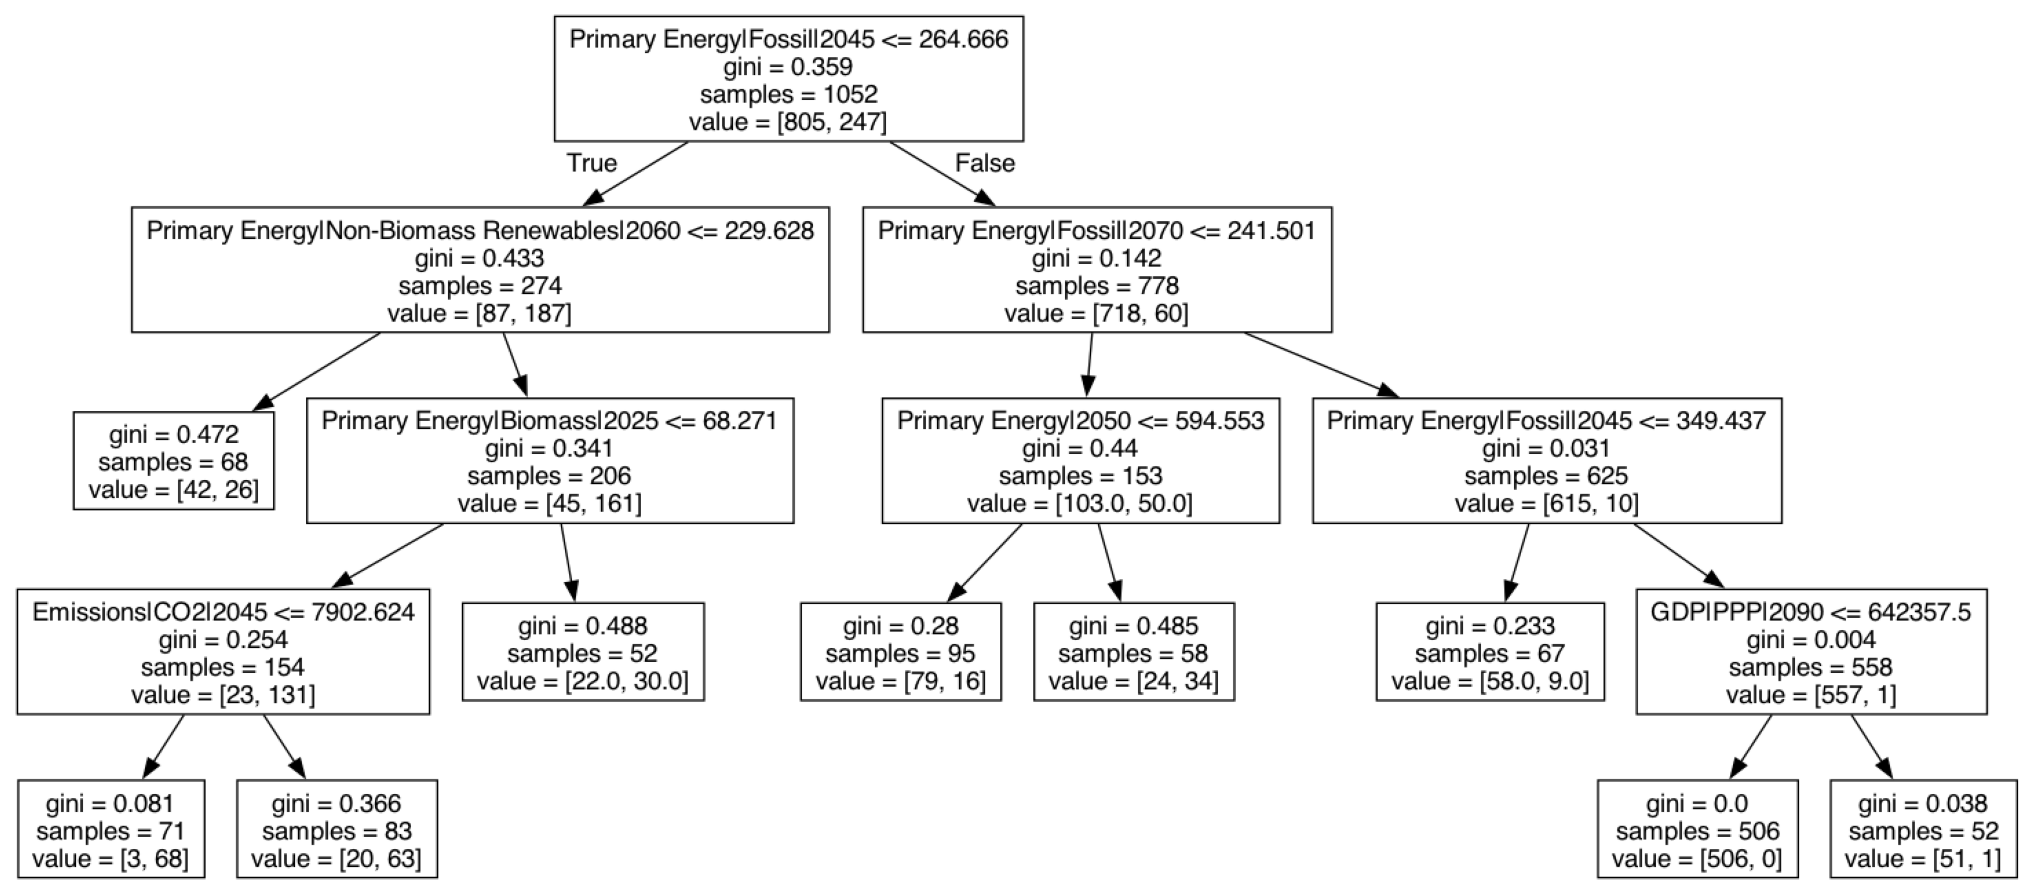

In [7]:
cart_alg_all = cart.CART(x_all, y_all)
cart_alg_all.build_tree()

fig = cart_alg_all.show_tree()
fig.set_size_inches((26, 15))
fig.savefig("cart_tree_all_variables.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
importances_all = pd.Series(
    cart_alg_all.clf.feature_importances_, index=ALL_FACTORS
).sort_values(ascending=False)
importances_all[importances_all > 0]

Primary Energy|Fossil|2045                    0.710088
Primary Energy|Fossil|2070                    0.111947
Primary Energy|Non-Biomass Renewables|2060    0.076820
Primary Energy|2050                           0.059270
Primary Energy|Biomass|2025                   0.027464
Emissions|CO2|2045                            0.014247
GDP|PPP|2090                                  0.000164
dtype: float64

## 3. PRIM: find the box(es) characterizing the desired region

`threshold` is PRIM's minimum acceptable density for the *final* box - if peeling can't reach it,
this implementation falls back to the trivial whole-space box. With baseline density at ~7%, we probe
what's actually achievable first instead of guessing a threshold.

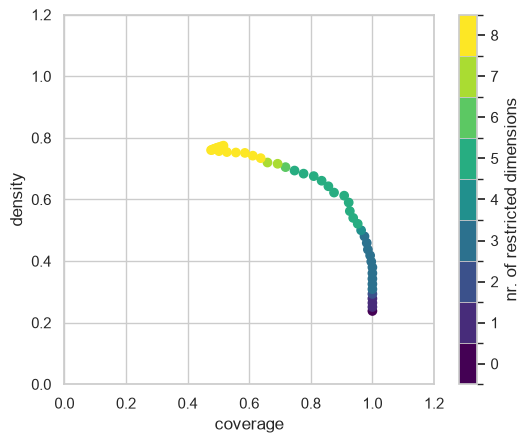

In [9]:
# Low, easily-satisfied threshold so we always get the real peeling trajectory back -
# we pick our preferred point on it ourselves in the next step, exactly like show_tradeoff()
# is meant to be used.
prim_alg = prim.Prim(x, y, threshold=0.1)
box1 = prim_alg.find_box()

box1.show_tradeoff()
plt.savefig("prim_tradeoff_box1.png", dpi=150)
plt.show()

In [10]:
box1.peeling_trajectory[["id", "coverage", "density", "mass", "res_dim"]]

,id,coverage,density,mass,res_dim
0,0,1.000000,0.238012,1.000000,0
1,1,1.000000,0.250919,0.948561,1
2,2,1.000000,0.264279,0.900610,1
3,3,1.000000,0.278287,0.855275,1
4,4,1.000000,0.293233,0.811683,2
5,5,1.000000,0.308824,0.770706,3
6,6,1.000000,0.325387,0.731473,3
7,7,1.000000,0.342535,0.694856,3
8,8,1.000000,0.360634,0.659983,3
9,9,1.000000,0.379694,0.626853,3


### Pick a point on the trade-off curve

`show_tradeoff()` is the human-in-the-loop step - there's no single correct box. As a starting pick we
favour **coverage** (don't miss desired scenarios) while taking the best density available at that
coverage level: among points with coverage >= 0.9, take the one with max density. Override
`selected_box` below to explore other points on the curve.

In [11]:
traj = box1.peeling_trajectory
candidates = traj[traj["coverage"] >= 0.9]
selected_box = int(candidates.loc[candidates["density"].idxmax(), "id"])
print(f"selected_box = {selected_box}")
traj.loc[traj["id"] == selected_box]

selected_box = 20


,coverage,density,id,k,mass,mean,n,res_dim
20,0.908425,0.612346,20,248,0.353095,0.612346,405,5


coverage      0.908425
density       0.612346
id           20.000000
k           248.000000
mass          0.353095
mean          0.612346
n           405.000000
res_dim       5.000000
Name: 20, dtype: float64

                                               box 20                          \
                                                  min           max  qp value   
Primary Energy|Fossil|2050                  42.077433    344.512725       NaN   
Emissions|CO2|2030                          -0.367922  47939.145950       NaN   
Primary Energy|Biomass|2050                 63.744090    310.100000  0.000030   
Primary Energy|Non-Biomass Renewables|2030  46.704999    145.316944  0.120173   
Primary Energy|Non-Biomass Renewables|2050  80.891938    473.451635  0.521850   

                                                      
                                            qp value  
Primary Energy|Fossil|2050                  0.000007  
Emissions|CO2|2030                          0.521850  
Pr

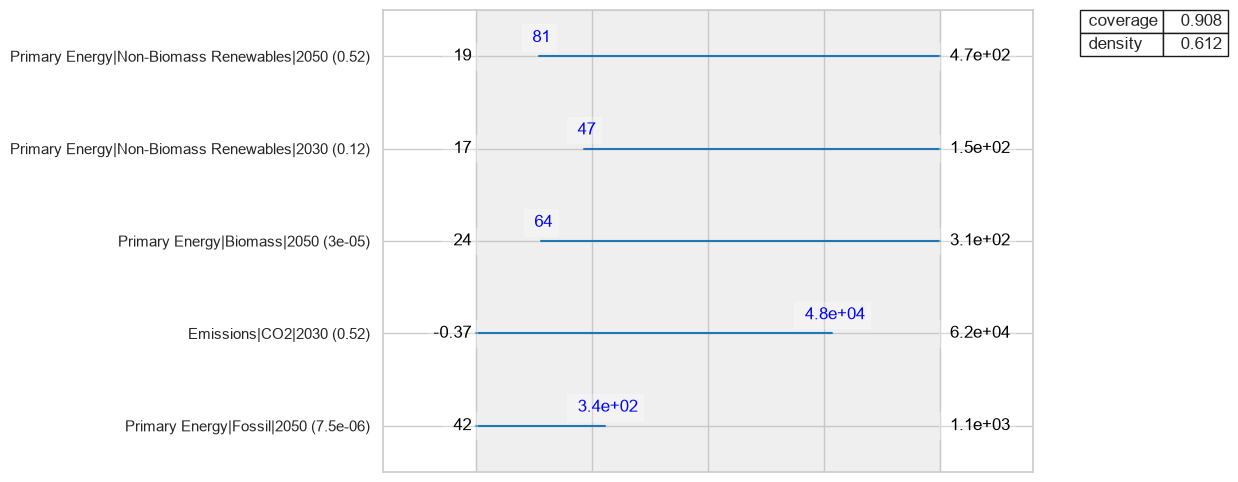

In [12]:
box1.select(selected_box)  # also tells PRIM what's "covered" for the residual search below

box1.inspect(selected_box)
box1.inspect(selected_box, style="graph")
plt.gcf().set_size_inches((10, 6))
plt.savefig("prim_box1_graph.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Equifinality: is there a second box?

Re-run `find_box()` on the residual cases of interest (those not yet covered by box 1) to see whether
desired scenarios concentrate via more than one distinct pathway.

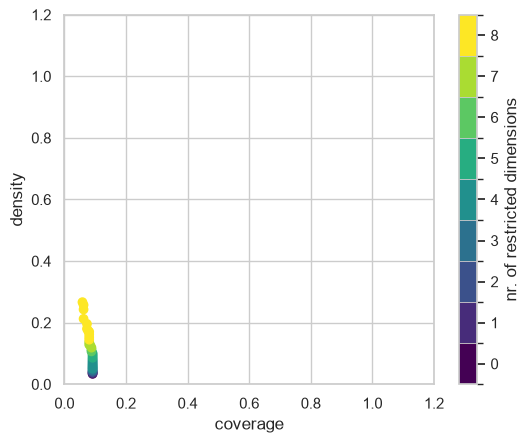

In [13]:
box2 = prim_alg.find_box()

if box2 is None:
    print("No data remaining - box 1 already covers every case of interest.")
else:
    box2.show_tradeoff()
    plt.savefig("prim_tradeoff_box2.png", dpi=150)
    plt.show()

In [14]:
prim_alg.stats_to_dataframe()

,coverage,density,mass,res_dim
box 1,0.908425,0.612346,0.353095,5
box 2,0.058608,0.266667,0.052310,8


## Caveat

These factors are mostly model **outputs**, not original model inputs (the ensemble is a heterogeneous
multi-model collection, not a controlled experiment) - so the box above is **descriptive/diagnostic**
("desired pathways tend to combine X and Y"), not a causal claim ("setting X causes desired outcomes").
It's also a single `tau`/threshold choice (NZ<=2070, CCS<=median) - per the methodology reference,
worth re-running with neighbouring thresholds before reporting the restricted dimensions as a stable
finding.